# Notebook 3: Visualising the Perceptron

Seeing is believing. In this notebook we **visualise** what the perceptron actually learns:

1. The **decision boundary** that separates vehicles from living beings
2. How the boundary **moves** during training
3. How **training error decreases** over epochs
4. Why the perceptron **fails** on non-linearly-separable data (XOR)

We use `matplotlib` for all plots.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Make plots look nice in the notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

## 1. Training Data (2-D Projection)

Our data has 3 features, but for plotting we'll use the two most discriminative ones: **Has Wheels** and **Can Breathe**. ("Is Round" is shared by both classes so it doesn't help separate them.)

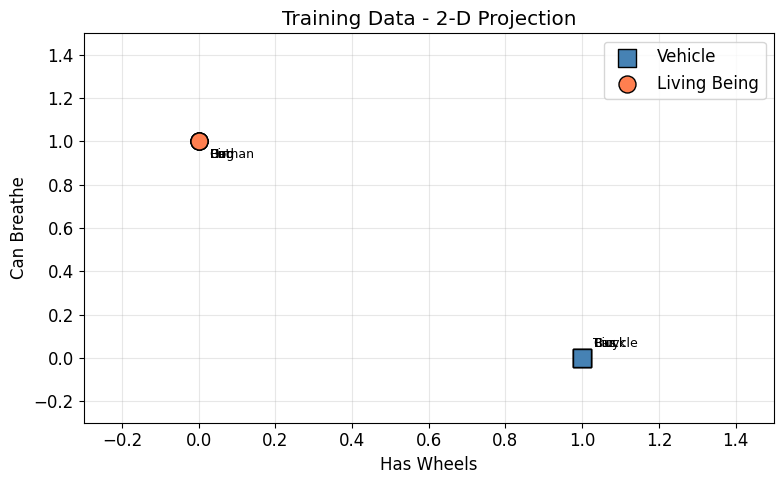

The two classes are clearly separable along these two features!


In [2]:
# Full 3-feature data
data_3d = [
    (np.array([1, 1, 0]), 1, "Car"),
    (np.array([0, 1, 0]), 1, "Truck"),
    (np.array([1, 1, 0]), 1, "Bicycle"),
    (np.array([0, 1, 0]), 1, "Bus"),
    (np.array([1, 0, 1]), 0, "Human"),
    (np.array([0, 0, 1]), 0, "Dog"),
    (np.array([0, 0, 1]), 0, "Cat"),
    (np.array([1, 0, 1]), 0, "Bird"),
]

# Extract 2-D projection: (Has Wheels, Can Breathe)
vehicles_x = [f[1] for f, l, _ in data_3d if l == 1]  # has_wheels
vehicles_y = [f[2] for f, l, _ in data_3d if l == 1]  # can_breathe
living_x   = [f[1] for f, l, _ in data_3d if l == 0]
living_y   = [f[2] for f, l, _ in data_3d if l == 0]

fig, ax = plt.subplots()
ax.scatter(vehicles_x, vehicles_y, c='steelblue', s=150, marker='s',
           edgecolors='k', label='Vehicle', zorder=3)
ax.scatter(living_x, living_y, c='coral', s=150, marker='o',
           edgecolors='k', label='Living Being', zorder=3)

# Annotate points
for feat, label, name in data_3d:
    offset = (8, 8) if label == 1 else (8, -12)
    ax.annotate(name, (feat[1], feat[2]), textcoords='offset points',
                xytext=offset, fontsize=9)

ax.set_xlabel('Has Wheels')
ax.set_ylabel('Can Breathe')
ax.set_title('Training Data - 2-D Projection')
ax.set_xlim(-0.3, 1.5)
ax.set_ylim(-0.3, 1.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The two classes are clearly separable along these two features!")

## 2. Train a 2-D Perceptron & Record History

To plot the decision boundary we train a perceptron on just the 2-D features and save the weights after every epoch.

In [3]:
# 2-D training data: (has_wheels, can_breathe)
X_train = np.array([
    [1, 0], [1, 0], [1, 0], [1, 0],   # vehicles
    [0, 1], [0, 1], [0, 1], [0, 1],   # living beings
])
y_train = np.array([1, 1, 1, 1, 0, 0, 0, 0])

# Initialise
np.random.seed(7)
w = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)
lr = 0.1

# Storage
weight_history = [(w.copy(), b)]  # initial weights
error_history  = []

for epoch in range(50):
    errs = 0
    for xi, yi in zip(X_train, y_train):
        pred = 1 if np.dot(w, xi) + b >= 0 else 0
        err = yi - pred
        if err != 0:
            errs += 1
            w = w + lr * err * xi
            b = b + lr * err
    weight_history.append((w.copy(), b))
    error_history.append(errs)
    if errs == 0:
        print(f"Converged in {epoch + 1} epoch(s).")
        break

print(f"Final weights: {np.round(w, 3)}, bias: {b:.3f}")

Converged in 5 epoch(s).
Final weights: [ 0.053 -0.14 ], bias: 0.077


## 3. Plot the Decision Boundary

The perceptron predicts class 1 when:

$$w_1 x_1 + w_2 x_2 + b \geq 0$$

The **decision boundary** is the line where this equals zero:

$$x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2}$$

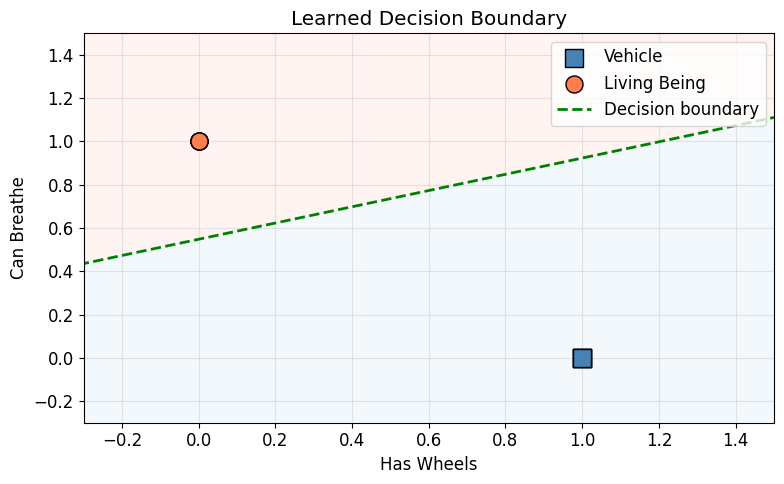

In [4]:
def plot_decision_boundary(w, b, ax, color='green', label='Decision boundary'):
    """Plot the line w1*x1 + w2*x2 + b = 0."""
    if abs(w[1]) < 1e-8:
        # Vertical line
        x1_val = -b / w[0]
        ax.axvline(x=x1_val, color=color, linestyle='--', linewidth=2, label=label)
    else:
        x1_vals = np.linspace(-0.5, 1.5, 200)
        x2_vals = -(w[0] * x1_vals + b) / w[1]
        ax.plot(x1_vals, x2_vals, color=color, linestyle='--', linewidth=2, label=label)


fig, ax = plt.subplots()

# Data points
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='steelblue', s=150, marker='s', edgecolors='k', label='Vehicle', zorder=3)
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           c='coral', s=150, marker='o', edgecolors='k', label='Living Being', zorder=3)

# Decision boundary
plot_decision_boundary(w, b, ax, color='green', label='Decision boundary')

# Shade the regions
xx = np.linspace(-0.5, 1.5, 300)
yy = np.linspace(-0.5, 1.5, 300)
XX, YY = np.meshgrid(xx, yy)
Z = w[0] * XX + w[1] * YY + b
ax.contourf(XX, YY, Z, levels=[-100, 0, 100], colors=['#FFDDD2', '#D6EAF8'], alpha=0.3)

ax.set_xlabel('Has Wheels')
ax.set_ylabel('Can Breathe')
ax.set_title('Learned Decision Boundary')
ax.set_xlim(-0.3, 1.5)
ax.set_ylim(-0.3, 1.5)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. How the Decision Boundary Evolves During Training

Let's show how the boundary moves from its random initial position to the final one across training epochs.

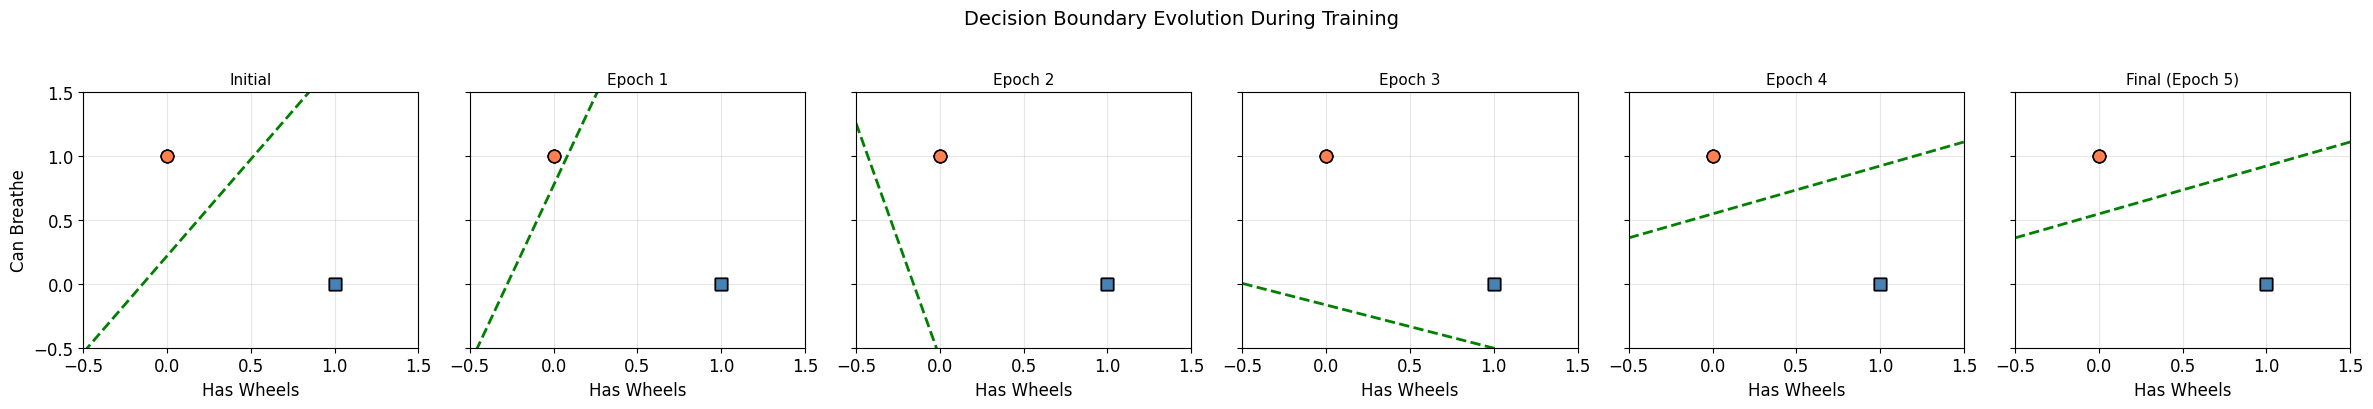

In [5]:
# Select a few snapshots to plot
n_snapshots = min(len(weight_history), 6)
indices = np.linspace(0, len(weight_history) - 1, n_snapshots, dtype=int)

fig, axes = plt.subplots(1, n_snapshots, figsize=(4 * n_snapshots, 4), sharey=True)
if n_snapshots == 1:
    axes = [axes]

for idx, ax_idx in enumerate(indices):
    ax = axes[idx]
    wi, bi = weight_history[ax_idx]

    ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
               c='steelblue', s=80, marker='s', edgecolors='k', zorder=3)
    ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
               c='coral', s=80, marker='o', edgecolors='k', zorder=3)
    plot_decision_boundary(wi, bi, ax, color='green')

    title = 'Initial' if ax_idx == 0 else f'Epoch {ax_idx}'
    if ax_idx == len(weight_history) - 1:
        title = f'Final (Epoch {ax_idx})'
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('Has Wheels')
    if idx == 0:
        ax.set_ylabel('Can Breathe')
    ax.grid(True, alpha=0.3)

plt.suptitle('Decision Boundary Evolution During Training', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Training Error Curve

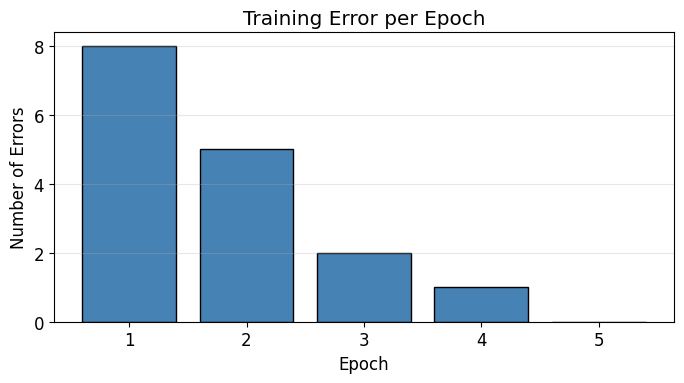

The perceptron went from 8 errors to 0 in 5 epoch(s).


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(error_history) + 1), error_history, color='steelblue', edgecolor='k')
ax.set_xlabel('Epoch')
ax.set_ylabel('Number of Errors')
ax.set_title('Training Error per Epoch')
ax.set_xticks(range(1, len(error_history) + 1))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The perceptron went from {error_history[0]} errors to 0 in {len(error_history)} epoch(s).")

## 6. The XOR Problem — Where Perceptrons Fail

The XOR function is the classic example of a **non-linearly-separable** problem:

| x1 | x2 | y |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 1 |
| 1  | 0  | 1 |
| 1  | 1  | 0 |

No single straight line can separate the 0s from the 1s. Let's prove it.

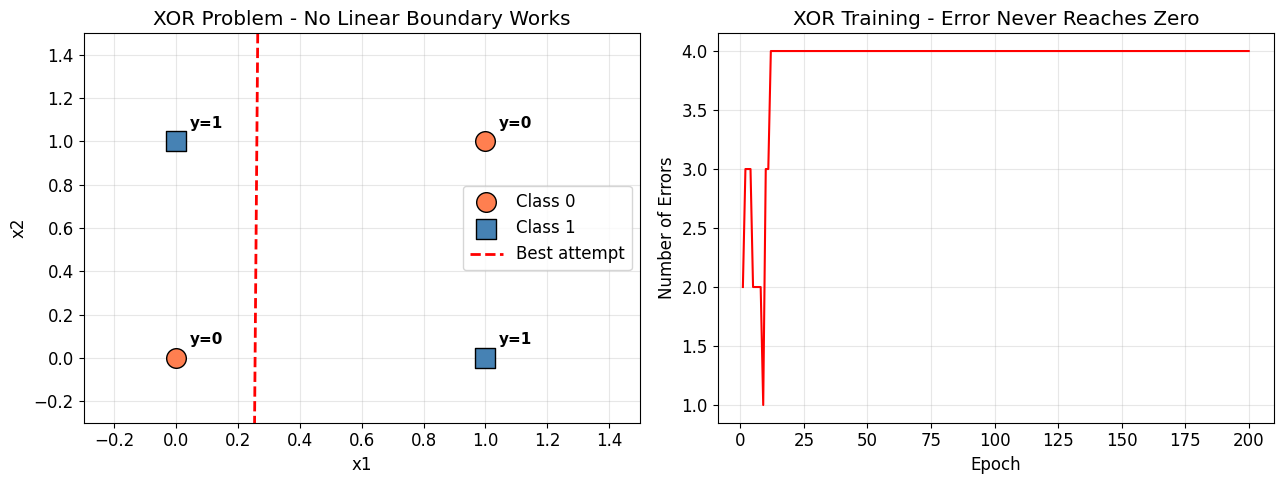

After 200 epochs the perceptron still has 4 error(s).
This is NOT a bug - XOR is simply not linearly separable.
You need a multi-layer network (MLP) to solve XOR.


In [7]:
# XOR data
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Try to train a perceptron on XOR
np.random.seed(42)
w_xor = np.random.uniform(-1, 1, size=2)
b_xor = np.random.uniform(-1, 1)
lr_xor = 0.1

xor_errors = []
for epoch in range(200):
    errs = 0
    for xi, yi in zip(X_xor, y_xor):
        pred = 1 if np.dot(w_xor, xi) + b_xor >= 0 else 0
        err = yi - pred
        if err != 0:
            errs += 1
            w_xor = w_xor + lr_xor * err * xi
            b_xor = b_xor + lr_xor * err
    xor_errors.append(errs)
    if errs == 0:
        break

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: data + attempted boundary
ax1.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1],
            c='coral', s=200, marker='o', edgecolors='k', label='Class 0', zorder=3)
ax1.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1],
            c='steelblue', s=200, marker='s', edgecolors='k', label='Class 1', zorder=3)
plot_decision_boundary(w_xor, b_xor, ax1, color='red', label='Best attempt')

# Annotate
for xi, yi in zip(X_xor, y_xor):
    ax1.annotate(f'y={yi}', (xi[0], xi[1]), textcoords='offset points',
                 xytext=(10, 10), fontsize=11, fontweight='bold')

ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_title('XOR Problem - No Linear Boundary Works')
ax1.set_xlim(-0.3, 1.5)
ax1.set_ylim(-0.3, 1.5)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: error over epochs
ax2.plot(range(1, len(xor_errors) + 1), xor_errors, color='red', linewidth=1.5)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Number of Errors')
ax2.set_title('XOR Training - Error Never Reaches Zero')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"After 200 epochs the perceptron still has {xor_errors[-1]} error(s).")
print("This is NOT a bug - XOR is simply not linearly separable.")
print("You need a multi-layer network (MLP) to solve XOR.")

## 7. Full 3-D Visualisation (Bonus)

Since our original data has 3 features, let's see it in 3-D!

3-D perceptron converged in 3 epoch(s).


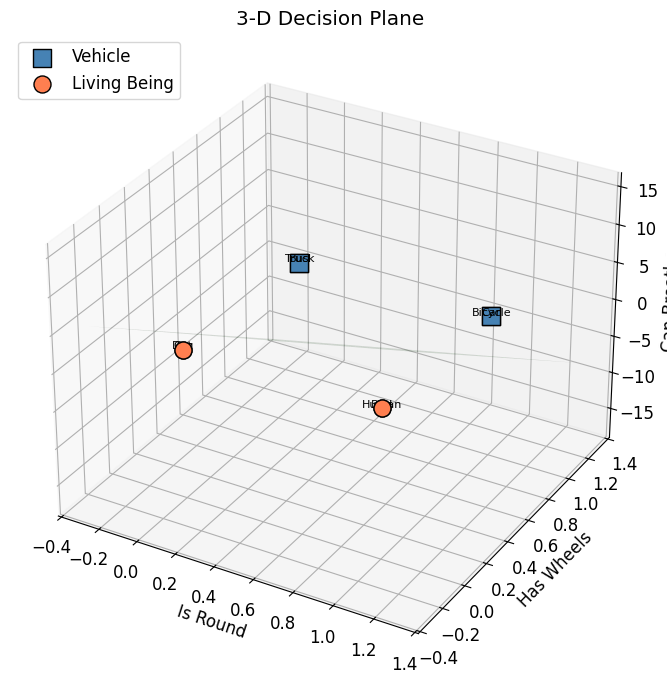

In [8]:
from mpl_toolkits.mplot3d import Axes3D

# Train on the full 3-D data
X_3d = np.array([f for f, _, _ in data_3d])
y_3d = np.array([l for _, l, _ in data_3d])
names = [n for _, _, n in data_3d]

np.random.seed(42)
w3 = np.random.uniform(-1, 1, size=3)
b3 = np.random.uniform(-1, 1)

for epoch in range(100):
    errs = 0
    for xi, yi in zip(X_3d, y_3d):
        pred = 1 if np.dot(w3, xi) + b3 >= 0 else 0
        err = yi - pred
        if err != 0:
            errs += 1
            w3 = w3 + 0.1 * err * xi
            b3 = b3 + 0.1 * err
    if errs == 0:
        print(f"3-D perceptron converged in {epoch + 1} epoch(s).")
        break

# 3-D scatter + decision plane
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Points
mask_v = y_3d == 1
mask_l = y_3d == 0
ax.scatter(X_3d[mask_v, 0], X_3d[mask_v, 1], X_3d[mask_v, 2],
           c='steelblue', s=150, marker='s', edgecolors='k', label='Vehicle', depthshade=False)
ax.scatter(X_3d[mask_l, 0], X_3d[mask_l, 1], X_3d[mask_l, 2],
           c='coral', s=150, marker='o', edgecolors='k', label='Living Being', depthshade=False)

# Annotate
for xi, name in zip(X_3d, names):
    ax.text(xi[0], xi[1], xi[2] + 0.08, name, fontsize=8, ha='center')

# Decision plane: w1*x1 + w2*x2 + w3*x3 + b = 0  =>  x3 = -(w1*x1 + w2*x2 + b) / w3
if abs(w3[2]) > 1e-8:
    xx_plane = np.linspace(-0.3, 1.3, 20)
    yy_plane = np.linspace(-0.3, 1.3, 20)
    XX_p, YY_p = np.meshgrid(xx_plane, yy_plane)
    ZZ_p = -(w3[0] * XX_p + w3[1] * YY_p + b3) / w3[2]
    ax.plot_surface(XX_p, YY_p, ZZ_p, alpha=0.15, color='green')

ax.set_xlabel('Is Round')
ax.set_ylabel('Has Wheels')
ax.set_zlabel('Can Breathe')
ax.set_title('3-D Decision Plane')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 8. Exercises

1. **Add noise** - slightly perturb feature values (e.g., add `np.random.normal(0, 0.1)`) and see how the boundary changes.
2. **Multiple learning rates** - train the 2-D perceptron with `lr = 0.01, 0.1, 0.5, 1.0` and overlay the error curves.
3. **Animate** - use `matplotlib.animation.FuncAnimation` to create a smooth animation of the boundary moving during training.
4. **Try AND and OR** - these are linearly separable. Train and plot their boundaries.

---

## 9. Summary

| Visualisation | What it showed |
|--------------|----------------|
| 2-D scatter | Vehicles and living beings are separable by "Has Wheels" and "Can Breathe" |
| Decision boundary | A straight line learned by the perceptron |
| Boundary evolution | The line starts random and adjusts epoch by epoch |
| Error curve | Errors drop to zero when data is linearly separable |
| XOR failure | No single line can solve XOR - need multi-layer networks |
| 3-D plane | In 3 dimensions the boundary becomes a plane |

---

### What's Next?

Now that you understand the perceptron, you're ready for:
- **Multi-Layer Perceptrons (MLPs)** - stacking neurons to solve non-linear problems
- **Backpropagation** - the algorithm that trains deep networks
- **Modern frameworks** - PyTorch and TensorFlow build on these same ideas